# Proyecto Sprint 14


## Descripción del proyecto

<span style="color:#064d83; font-weight:bold;">Analizaremos los datos de una cadena de gimnasios que está desarrollando una estrategia de interacción con clientes basada en datos analíticos. 
<span style="color:#064d83; font-weight:bold;">La tarea principal consiste en aprender a predecir la probabilidad de pérdida para cada cliente y elaborar una estrategia de retención, analizando principalmente los factores que más impactan la pérdida.</span>


### 0. Librerías

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from sklearn.datasets import make_regression, make_classification

### 1. Carga de Datos

In [38]:
df = pd.read_csv('gym_churn_us.csv')

In [39]:
df.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


### 2. Analisis Exploratorio

In [40]:
# Exploración general

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [41]:
# Estudiar los valores promedio y la desviación estándar con el método describe()

df.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


### 3. Análisis Comparativo 

In [42]:
# Observar valores medios de las características en dos grupos: para las personas que se fueron (cancelación) y para las que se quedaron

df.groupby('Churn').mean(numeric_only=True)

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


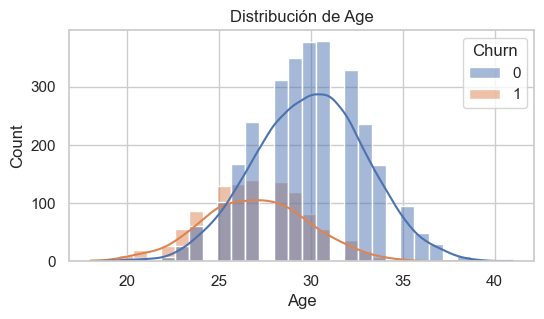

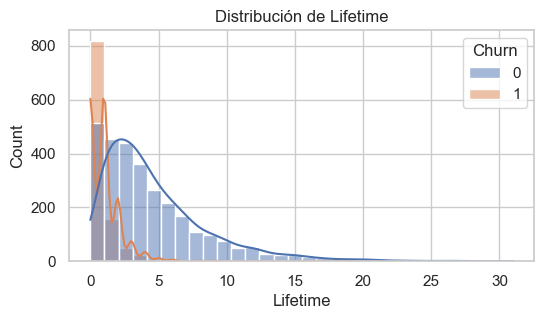

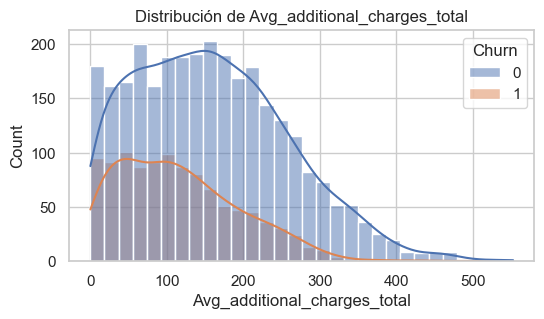

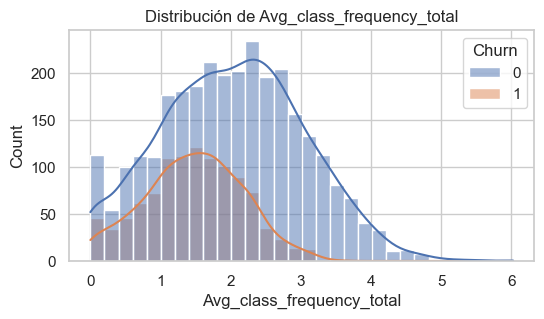

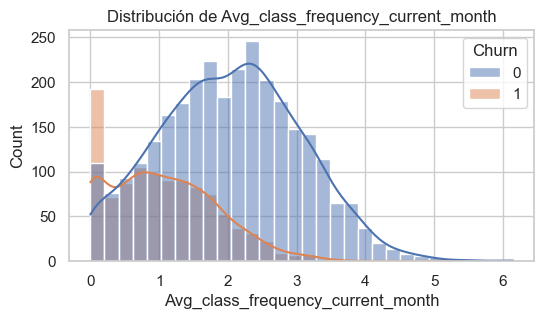

In [43]:
# Trazar histogramas de barras y distribuciones de características para aquellas personas que se fueron y para las que se quedaron

columns_to_plot = ['Age', 'Lifetime', 'Avg_additional_charges_total', 
                   'Avg_class_frequency_total', 'Avg_class_frequency_current_month']

for col in columns_to_plot:
    plt.figure(figsize=(6,3))
    sns.histplot(data=df, x=col, hue='Churn', kde=True, bins=30)
    plt.title(f'Distribución de {col}')
    plt.show()

<span style="color:#064d83; font-weight:bold;">Para la distribución que toma en cuenta la edad,</span><span style="color:#064d83;"> observamos que los usuarios más jóvenes son los que mas deciden irse.

<span style="color:#064d83; font-weight:bold;">Para lifetime</span><span style="color:#064d83;"> los usuarios que mas se van lo hacen durante los 2 primeros meses en su mayoría.

<span style="color:#064d83; font-weight:bold;">En Avg_additional_charges_total</span><span style="color:#064d83;"> los usuarios mas leales son los que mas gastan mientras que los que se van gastan menos.

<span style="color:#064d83; font-weight:bold;">Para la gráfica Avg_class_frequency_total</span><span style="color:#064d83;"> los usuarios que van de 1 a 3 veces por semana son los que son mas propensos a irse.

<span style="color:#064d83; font-weight:bold;">En Avg_class_frequency_current_month</span><span style="color:#064d83;"> los usuarios que dejan en su mayoría en gimnasio son los que se encuentran en su primer mes.

#### Matriz de Correlación


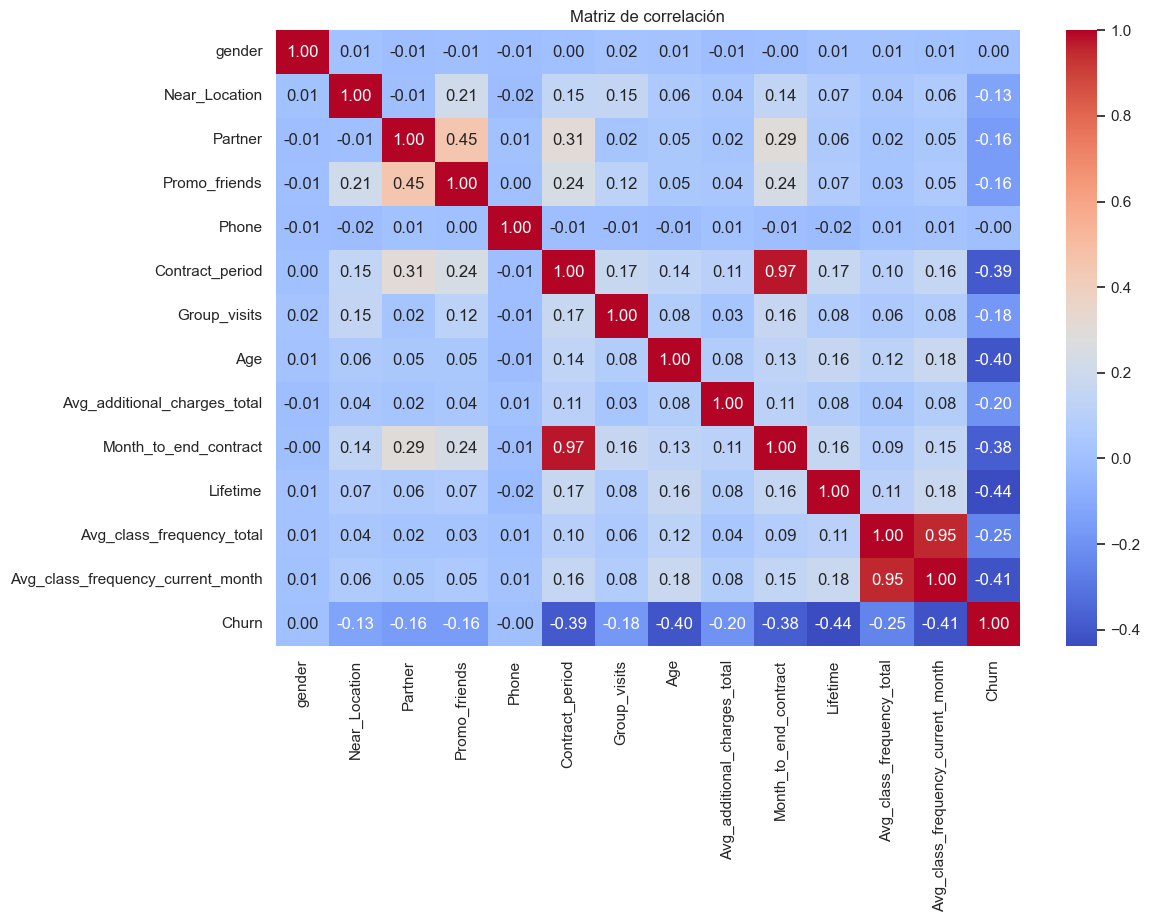

In [44]:
# Crear una matriz de correlación

numeric_df = df.select_dtypes(include=['number']) #Filtrar las columnas numéricas antes de calcular la correlación

corr = numeric_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

<span style="color:#064d83;">La matriz de correlación nos muestra que las caractrísticas con mayor importancia que probablemente determinan que un usuario no se vaya son: <span style="color:#064d83; font-weight:bold;">Lifetime, Age, Contract_period y Avg_class_frequency_current_month.</span><span style="color:#064d83;"> 
<span style="color:#064d83;"> Como nuestro objetivo es evitar que los clientes se vayan, se identifican las características mas alejadas de 1 que en este caso es el valor de Churn, nuestra variable objetivo.

### 4. Modelo de Cancelación

In [45]:
# Crear un modelo de clasificación binaria para clientes donde la característica objetivo es que los usuarios se vayan el mes siguiente

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42) # Dividir en conjuntos de entrenamiento 

# Regresión logística

log_model = LogisticRegression()
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_valid)

# Bosque aleatorio

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_valid)

# Evaluar la exactitud, precisión y recall para ambos modelos

print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_valid, log_pred))
print("Precision:", precision_score(y_valid, log_pred))
print("Recall:", recall_score(y_valid, log_pred))

print("\nRandom Forest:")
print("Accuracy:", accuracy_score(y_valid, rf_pred))
print("Precision:", precision_score(y_valid, rf_pred))
print("Recall:", recall_score(y_valid, rf_pred))

c:\Users\hp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression:
Accuracy: 0.92
Precision: 0.8791208791208791
Recall: 0.7920792079207921

Random Forest:
Accuracy: 0.9133333333333333
Precision: 0.8592057761732852
Recall: 0.7854785478547854


<span style="color:#064d83;">Los resultados de ambos modelos son buenos sin embargo el que da mejores resultados es <span style="color:#064d83; font-weight:bold;">Logistic Regression:</span><span style="color:#064d83;"> El porcentaje de exactitud es superior a Random Forest así como la precisión y con recall detecta el 80% de los usuarios que podrían irse.

### 5. Clústeres de Usuarios

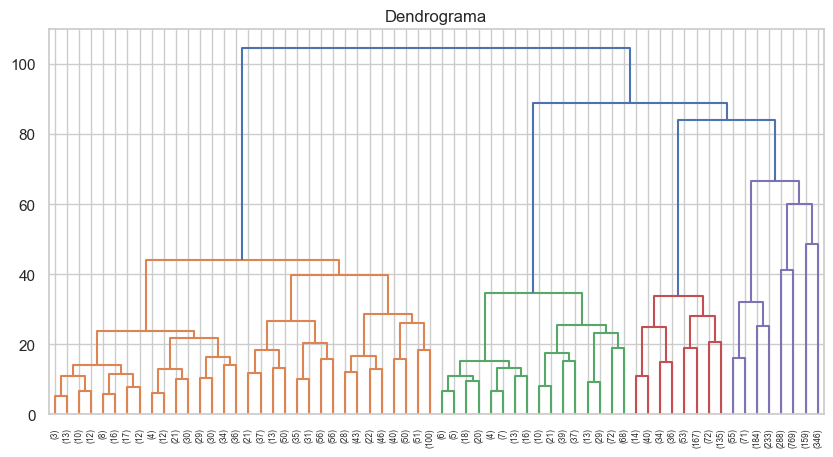

In [46]:
#  Identificar los clústeres de objetos

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

X_clust = df.drop('Churn', axis=1) #Eliminar la columna churn para evitar patrones
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

# Graficar un dendrograma
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Dendrograma')
plt.show()

<span style="color:#064d83; font-weight:bold;"> Utilizamos el dendograma para visualizar los grupos sugeridos de usuarios que usaremos en agrupamiento con K-means

In [47]:
# K-means con 5 clústeres

kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Características promedio por clúster

df.groupby('cluster').mean(numeric_only=True)

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
cluster,,,,,,,,,,,,,,
0,0.484801,0.698363,0.301637,0.007015,0.899454,1.733437,0.255651,28.074825,127.131782,1.657833,2.089634,1.256531,0.991781,0.587685
1,0.494471,0.947867,0.791469,0.998420,0.906793,2.740916,0.431280,28.903633,139.456908,2.540284,3.529226,1.619489,1.488508,0.285940
2,0.464396,0.913313,0.766254,0.493808,0.925697,10.495356,0.506192,30.091331,164.190347,9.484520,4.693498,2.888801,2.886027,0.013932
3,0.547794,0.937500,0.742647,0.424632,0.863971,11.194853,0.575368,29.720588,167.670439,10.347426,4.818015,1.154578,1.139605,0.042279
4,0.568233,0.878076,0.178971,0.048098,0.914989,2.120805,0.456376,29.993289,155.602830,2.013423,4.844519,2.667290,2.650122,0.105145


<span style="color:#064d83; font-weight:bold;">Analizando los resultados del agrupamiento descubrimos que el grupo con mas porcentaje de usuarios que se van es el 3</span><span style="color:#064d83;"> con 57% en Churn. Promo_friends es bajo por lo que no van recomendados por amigos y la frecuencia con la que asisten en baja también.

<span style="color:#064d83; font-weight:bold;">El grupo con mayor lealtad es el 2,</span><span style="color:#064d83;"> el porcentaje en Churn es solo del 2%. La duración del contrato es de casi un año y Lifetime muestra antiguedad de casi 5 meses en promedio.


<span style="color:#064d83; font-weight:bold;">Para el grupo 0</span><span style="color:#064d83;"> las características que mas sobresalen son Pomo_friends lo que indica que fueron recomendados por amigos. Partner también es elevado, lo que nos dice que vienen de empresas. Churn es moderado aunque no tan bajo como el grupo 2.

<span style="color:#064d83; font-weight:bold;">Para el grupo 1</span><span style="color:#064d83;"> las características predominantes son Avg_class_frequency_current_month lo que indica que los usuarios entrenan casi 3 veces por semana, siendo el grupo con mas visitas por semana. El gasto en servicios adicionales también es elevado y Churn es bajo con solo el 8% de ussuarios que se van.

<span style="color:#064d83; font-weight:bold;">El grupo 4</span><span style="color:#064d83;"> también muestra Churn miderado y en general en la mayoría de las características comparten el nivel promedio. La única característica diferente al resto de los grupos es Phone, en este grupo los usuarios no tienen datos de contacto.

#### Distribuciones de Caractarísticas para los Clústeres

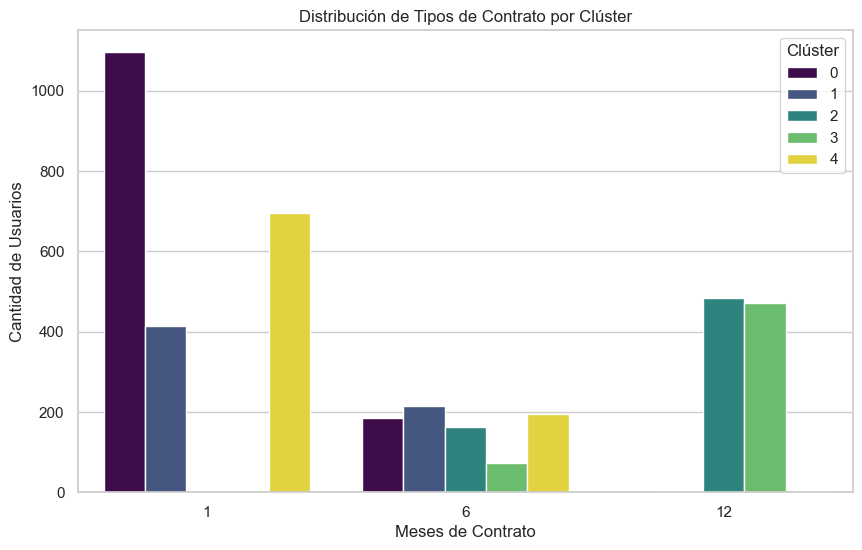

In [48]:
# Gráfico de barras para observar la distribución de contratos 

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.countplot(x='Contract_period', hue='cluster', data=df, palette='viridis')
plt.title('Distribución de Tipos de Contrato por Clúster')
plt.xlabel('Meses de Contrato')
plt.ylabel('Cantidad de Usuarios')
plt.legend(title='Clúster')
plt.show()

<span style="color:#064d83; font-weight:bold;">Gráfico de barras para analizar la característica 'Contract_period':</span><span style="color:#064d83;"> Podemos observar que el grupo 3 tiene el mayor número de contratos en el mes 1 lo que indica que son propensos a irse antes mienstras que el grupo 2 es el que muestra que los contratos están concentrados en el mes 12 lo que nos dice que para éste grupo de usuarios la probabilidad de que se vayan es baja ya que teniendo contratos por un año se garantiza su retención.

C:\Users\hp\AppData\Local\Temp\ipykernel_5972\2807735941.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='Age', data=df, palette='viridis')


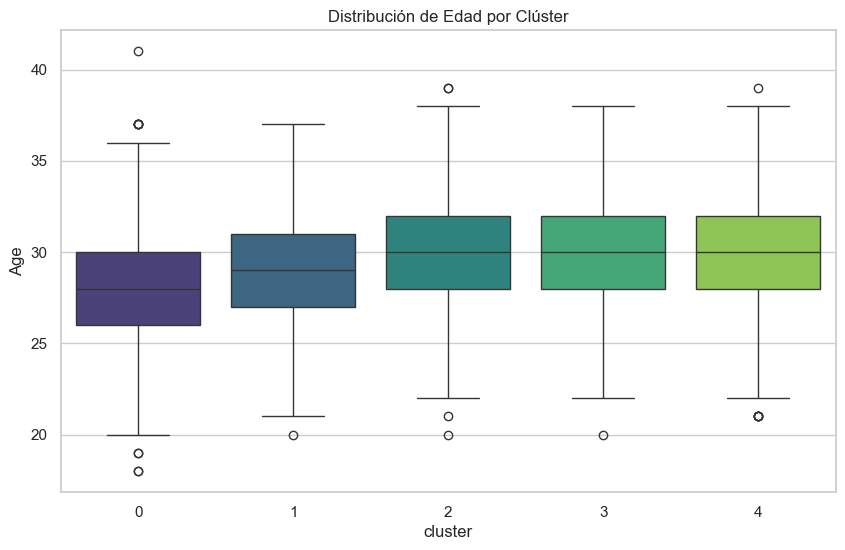

In [49]:
# Graficar un diagrama de caja para observar la distribución de la edad

plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='Age', data=df, palette='viridis')
plt.title('Distribución de Edad por Clúster')
plt.show()

<span style="color:#064d83; font-weight:bold;">Diagrama de caja para analizar la característica 'Age': </span><span style="color:#064d83;">Las cajas de los grupos 1 y 2 nos muestran que son en donde se encuentran los usuarios con mayor edad (alrededor de los 30 años), mientras que para el grupo 3 el promedio de la edad es de usuarios más jóvenes lo que puede ser un indicador de perfiles con mayor probabilidad a irse.

C:\Users\hp\AppData\Local\Temp\ipykernel_5972\533433486.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='Avg_class_frequency_current_month', data=df, palette='viridis')


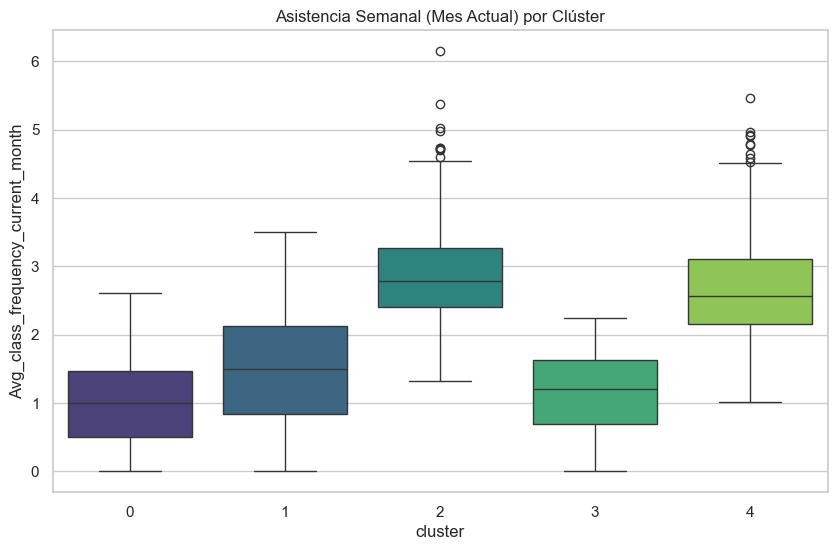

In [50]:
# Graficar un diagrama de caja para observar la frecuencia de asistencia por semana en el mes actual

plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='Avg_class_frequency_current_month', data=df, palette='viridis')
plt.title('Asistencia Semanal (Mes Actual) por Clúster')
plt.show()

<span style="color:#064d83; font-weight:bold;">Diagrama de caja para analizar la característica 'Avg_class_frequency_current_month': </span><span style="color:#064d83;">Revisamos cuántas veces por semana asisten los usuarios al gimnasio y observamos que para el grupo 3 el promedio de visitas es de 1 visita a la semana por lo que parece ser el grupo mas vulnerable a abandonar mientras que en el grupo 1 el promedio es de casi 3 visitas por semana incluso a pesar de dejar fuera los outliers que son mas visibles en este grupo, se observa el compromiso y menos probabilidades de dejar de asistir.

C:\Users\hp\AppData\Local\Temp\ipykernel_5972\2993233041.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='Avg_additional_charges_total', data=df, palette='viridis')


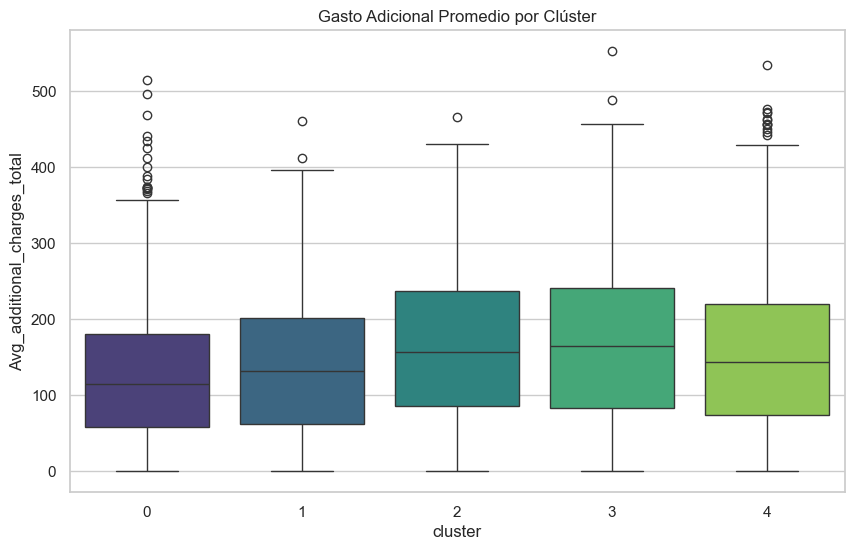

In [51]:
# Graficar un diagrama de caja para identificar a los usuarios que mas gastan en servicios adicionales

plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='Avg_additional_charges_total', data=df, palette='viridis')
plt.title('Gasto Adicional Promedio por Clúster')
plt.show()

<span style="color:#064d83; font-weight:bold;">Diagrama de caja para analizar la característica 'Avg_additional_charges_total': </span><span style="color:#064d83;"> Analizamos cuánto dinero gastan los usuarios en servicios extra identificando que el grupo 2 tiene el promedio mas alto con el grupo de usuarios que mas gasta mientras que el grupo 3 demuestra tener el grupo que menos gasta en este tipo de servicios adicionales.

#### Calcular la Tasa de Cancelación

In [52]:
# Calcular la tasa de cancelación para cada clúster utilizando el método groupby()

df.groupby('cluster')['Churn'].mean()

cluster
0    0.587685
1    0.285940
2    0.013932
3    0.042279
4    0.105145
Name: Churn, dtype: float64

C:\Users\hp\AppData\Local\Temp\ipykernel_5972\1925981443.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cluster', y='Churn', data=df, palette='Reds')


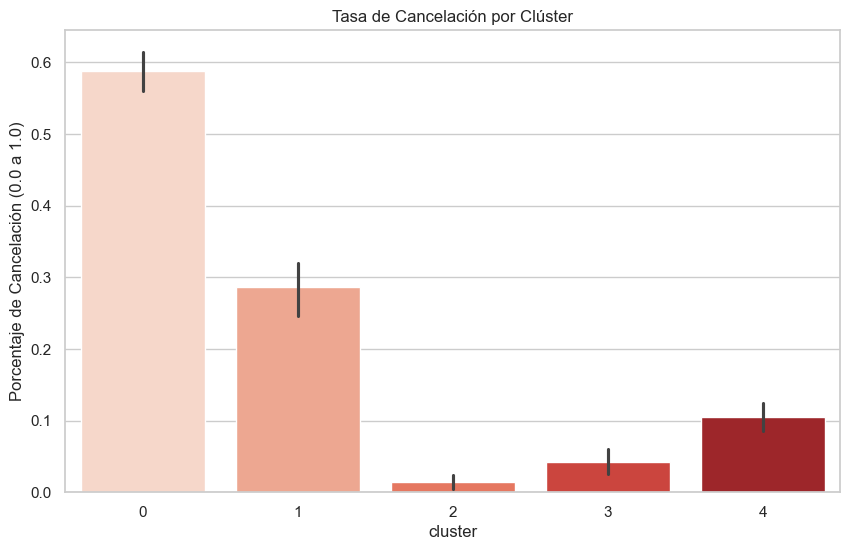

In [53]:
# Viasualizar un gráfico de barras para mostrar la Tasa de Cancelación por cluster

plt.figure(figsize=(10, 6))
sns.barplot(x='cluster', y='Churn', data=df, palette='Reds')
plt.title('Tasa de Cancelación por Clúster')
plt.ylabel('Porcentaje de Cancelación (0.0 a 1.0)')
plt.show()

<span style="color:#064d83; font-weight:bold;">Gráfico de barras para analizar la Tasa de Cancelación con la variable objetivo 'Churn': </span><span style="color:#064d83;"> Podemos observar el porcentaje promedio de usuarios que se fueron en donde el grupo 3 muestra el porcentaje mas alto (mas del 50%) mientras que el grupo 2 tiene el porcentaje mas bajo.

#### ¿Qué grupos son propensos a irse y cuáles son leales?

<span style="color:#064d83; font-weight:bold;">Con base en el análisis de los gráficos anteriores: </span><span style="color:#064d83;"> Podemos observar que el grupo 3 tiene el mayor porcentaje de usuarios que abandonan y al mismo tiempo en el gráfico de barras donde se analizan los contratos es el grupo con el plazo mas corto lo que hace suponer que <span style="color:#064d83; font-weight:bold;">el grupo 3 es clúster con los usuarios mas propensos a irse.</span> Por el contrario el grupo 2 tiene el porcentaje mas bajo de usuarios que se van y comparándo el mismo grupo en el análisis de los contratos, son el grupo con el periodo mas largo, con un promedio de 1 año lo que indica que <span style="color:#064d83; font-weight:bold;">el grupo 2 es el mas leal.

### 5. Conclusiones

<span style="color:#064d83;">Con base en el análisis de clústeres utilizando K-Means se identifica al clúster 3 como el grupo con más usuarios propensos a abandonar porque tienen poca asistencia y sus contratos son de 1 mes de duración, mientras que los usuarios más leales se encuentran en el clúster 0 y 2 pues tienen la tasa de cancelación más baja; el clúster 2 tiene a los usuarios con contratos más largos y el clúster 0 a los usuarios que están inscritos gracias a un amigo.

#### <span style="color:#064d83; font-weight:bold;">Principios Escenciales

<span style="color:#064d83; font-weight:bold;">1 Basándonos en la matriz de relacion, existe una correlación directa entre contratos de 1 mes y el abandono (Churn del 57% en el clúster 3).</span><span style="color:#064d83;"> Como estratégia para la retención se puede lanzar una campaña que ofrezca un descuento después de que finalice el primer mes para usuarios que contraten por 6 meses. 

<span style="color:#064d83; font-weight:bold;">2 Los diagramas de caja muestran mas detalladamente que la asistencia fue un factor que demostró que los usuarios que dejaron de ir antes de cumplir el primer mes cancelaron.</span><span style="color:#064d83;"> Como estratégia para la retención se pueden enviar mensajes a los usuarios que se detectan con inactividad por periodos prolongados ofreciendo un descuento especial si cumplen un número determinado de visitas antes de finalizar el mes; esto con la finalidad de incentivar la asistencia y reducir el risgo de abandono.

<span style="color:#064d83; font-weight:bold;">3 También los diagramas de caja nos permiten ver de cerca que los factores sociales como el ser invitado por un amigo o participar en sesiones grupales son caracterísitcas que arrojan un porcentaje muy bajo y que comparten los usuarios del clúster 3 que es el grupo con el mayor porcentaje de abandono.</span><span style="color:#064d83;"> Como estratégia para la retención se puede implementar un día al mes para traer un invitado sin costo, acción que puede impulsar a que los usuarios se comprometan a asisitir y al mismo tiempo una posible referencia para el gimnasio.
